## Neural Network
This file is about using neural network to train a model to predict rating 3.0 of a player.

In [1]:
import pandas as pd
df = pd.read_excel('preprocessed_data.xlsx')
display(df.head())

,Player,Rating 3.0,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,donk,1.38,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,ZywOo,1.34,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,m0NESY,1.26,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,Luken,1.24,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,Frip,1.23,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


### 1. Data Preparation and Splitting

First, I'll define the features (`X`) and the target variable (`y`). Then, I'll split the data into training, validation, and test sets using `train_test_split` from `sklearn.model_selection`.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define target variable (y) and features (X)
y = df['Rating 3.0']
X = df.drop(columns=['Player', 'Rating 3.0'])

# Display target variable (y) and features (X)
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
display(X.head())
display(y.head())

Features (X) shape: (453, 37)
Target (y) shape: (453,)


,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,Opening deaths traded percentage,Assits per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,-0.220940,0.584043,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,-0.498507,-0.346455,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,0.241671,-1.587118,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,-0.637290,0.894209,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,-0.683551,1.824707,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


,Rating 3.0
0,1.38
1,1.34
2,1.26
3,1.24
4,1.23


In [3]:
# Split data into training (70%), validation (15%), and test (15%) sets

# First split: 85% for train+validation, 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the train+validation set, take 15/(100-15) for validation and the rest for training
# This makes the validation set approximately 15% of the total dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15 / 0.85), random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 317 samples
Validation set size: 68 samples
Test set size: 68 samples


### 2. Neural Network

In [4]:
# Helper function to calculate MSE
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Helper function to calculate MAE
def calculate_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Helper function to calculate R2 Score
def calculate_r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    return 1 - (ss_res / ss_total)

#### 2.1 Neural Network

Now, let's implement a neural network.

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the Neural Network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)), # Input layer + Hidden Layer 1
    layers.Dense(8, activation='relu'), # Hidden Layer 2
    layers.Dense(1, activation='linear') # Output Layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

print("Neural Network Model Defined and Compiled.")

Neural Network Model Defined and Compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Model Training Complete.


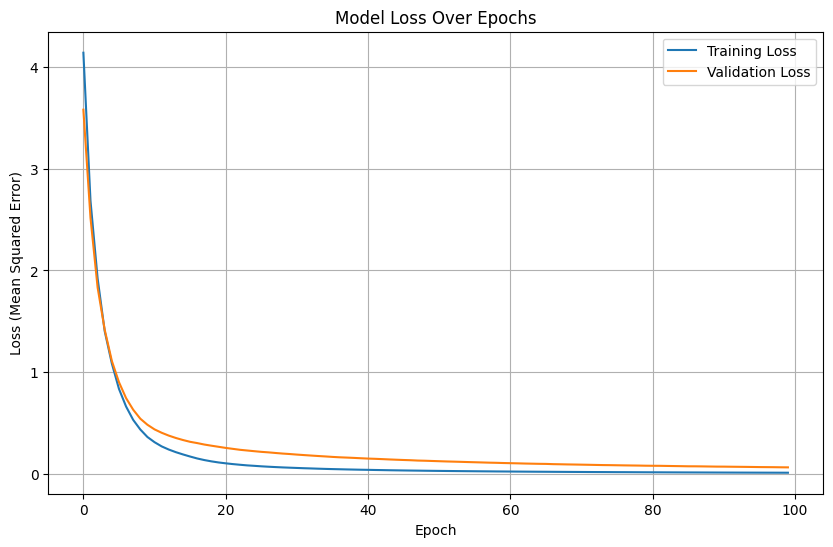

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val),
    verbose=0 # Set to 1 or 2 for more detailed output during training
)

print("Neural Network Model Training Complete.")

# Plot training history (loss over epochs)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

#### 2.2 Visualizing Performance Metrics

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions using the neural network model
y_train_pred_nn = model.predict(X_train).flatten()
y_val_pred_nn = model.predict(X_val).flatten()
y_test_pred_nn = model.predict(X_test).flatten()

# Convert y_true Series to numpy arrays for calculations
y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

# Calculate metrics for each set
mae_train_nn = calculate_mae(y_train_np, y_train_pred_nn)
mse_train_nn = calculate_mse(y_train_np, y_train_pred_nn)
rmse_train_nn = np.sqrt(mse_train_nn)

mae_val_nn = calculate_mae(y_val_np, y_val_pred_nn)
mse_val_nn = calculate_mse(y_val_np, y_val_pred_nn)
rmse_val_nn = np.sqrt(mse_val_nn)

mae_test_nn = calculate_mae(y_test_np, y_test_pred_nn)
mse_test_nn = calculate_mse(y_test_np, y_test_pred_nn)
rmse_test_nn = np.sqrt(mse_test_nn)

# Create a DataFrame to display results for MAE, MSE, RMSE
performance_df_nn = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Training Set': [mae_train_nn, mse_train_nn, rmse_train_nn],
    'Validation Set': [mae_val_nn, mse_val_nn, rmse_val_nn],
    'Test Set': [mae_test_nn, mse_test_nn, rmse_test_nn]
})

print("Neural Network Performance:")
display(performance_df_nn)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Neural Network Performance:


,Metric,Training Set,Validation Set,Test Set
0,MAE,0.088133,0.191009,0.134252
1,MSE,0.012106,0.064929,0.029746
2,RMSE,0.110028,0.254811,0.172469


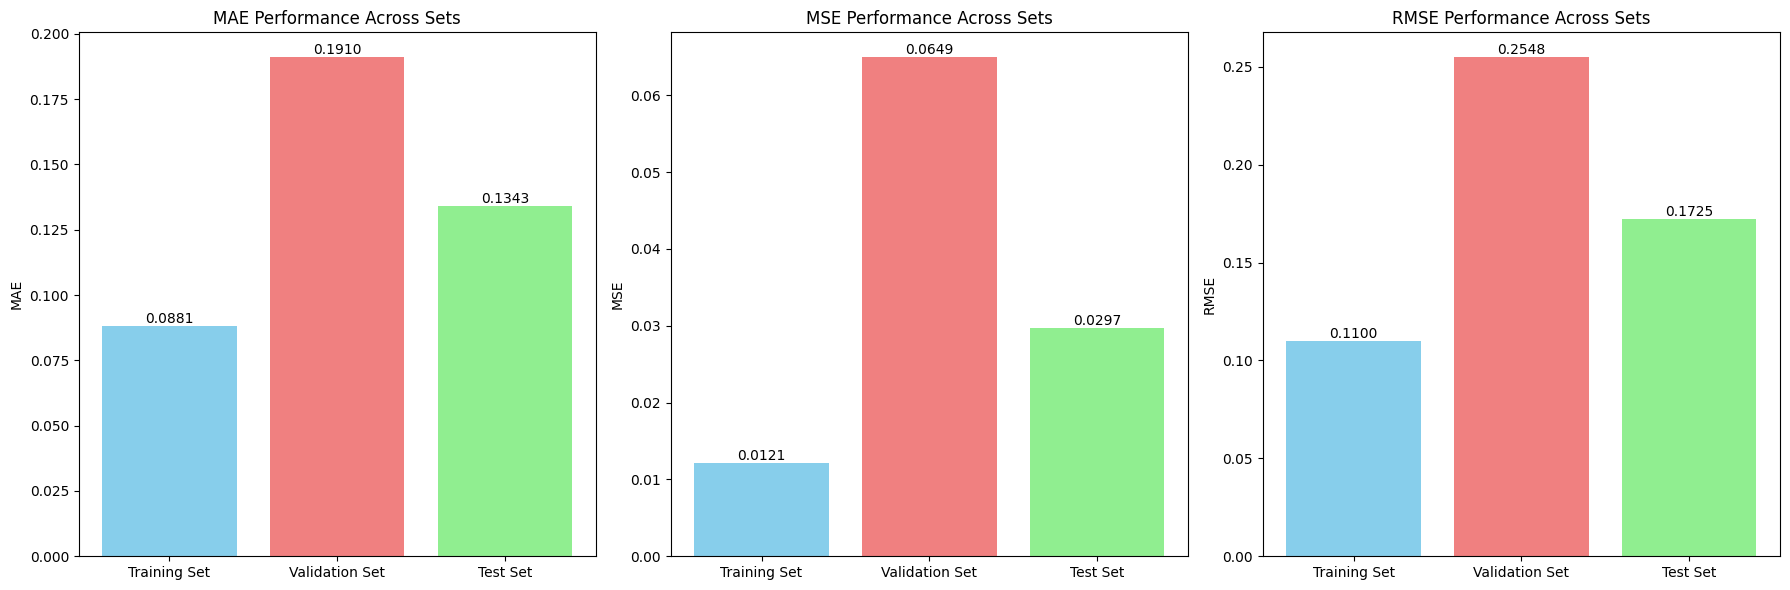

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjusted subplot count to 3 for MAE, MSE, RMSE
axes = axes.flatten()

metrics_to_plot = ['MAE', 'MSE', 'RMSE'] # Only plot these metrics
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, metric in enumerate(metrics_to_plot):
    metric_values = performance_df_nn[performance_df_nn['Metric'] == metric].iloc[0, 1:].values
    sets = ['Training Set', 'Validation Set', 'Test Set']

    axes[i].bar(sets, metric_values, color=colors)
    axes[i].set_title(f'{metric} Performance Across Sets')
    axes[i].set_ylabel(metric)
    for j, val in enumerate(metric_values):
        axes[i].text(j, val, f'{val:.4f}', ha='center', va='bottom')

    axes[i].autoscale(enable=True, axis='y', tight=False)

plt.tight_layout()
plt.show()